# Optimization: Experience Replay, Reward Shaping, and Hyperparameter Tuning

## 📚 Learning Objectives

By completing this notebook, you will:
- Understand and implement experience replay
- Apply reward shaping techniques
- Perform hyperparameter tuning for Deep RL
- Compare optimization techniques
- Improve learning efficiency

## 🔗 Prerequisites

- ✅ Understanding of Deep RL algorithms
- ✅ Understanding of neural networks
- ✅ Python knowledge
- ✅ NumPy, collections knowledge

---

## Official Structure Reference

This notebook covers practical activities from **Course 09, Unit 3**:
- Optimization: experimenting with techniques like experience replay, reward shaping, and hyperparameter tuning to improve learning efficiency

---

## Introduction

**Optimization techniques** like experience replay, reward shaping, and hyperparameter tuning are crucial for improving Deep RL training efficiency and performance.

## Lesson Brief

This lesson focuses on practical techniques that make deep RL training work better, such as replay and reward design choices.

Students will see that performance often depends not only on the algorithm name, but also on the way data, targets, and rewards are handled.

Why this matters: this lesson teaches engineering judgment, not only mathematical definitions.

It helps students understand why implementation choices strongly affect RL outcomes.

### If Python feels hard right now

- Run code cells **from top to bottom** the first time; later you can re-run one cell after you change it.
- In code cells, a line that starts with `# ` (hash + space) is a **hint for the very next line**—read the hint, then read the code under it.
- You do **not** need to memorize syntax. Follow the story: *what is stored*, *what gets printed*, and *what the plot is trying to show*.
- If something errors, read the last line of the red traceback first—it usually names the problem in plain language.


## Recommended YouTube Video

To reinforce this lesson, watch **Machine Learning with Phil - "Mastering Robotics with Hindsight Experience Replay | Paper Analysis"**:
[Watch on YouTube](https://www.youtube.com/watch?v=tmjLvRc5ZsQ)

Why this pick:
- discussion of sparse rewards in practice.
- Directly compares hindsight replay ideas against manual reward shaping trade-offs.
- Helpful when students need intuition for why training stability often depends on better replay or reward design.

## Student Support Pack

Use this section as a checkpoint before and after the main code cells so the idea stays clearer than the syntax.

### Key Terms
- Agent: the decision maker.
- Environment: the world it acts in.
- Reward: feedback signal.
- Return: long-term reward total.

### Quick Check
- What core RL idea does this notebook teach?
- Which output best reflects the main concept?
- How would you explain this topic in one minute?

### Common Mistakes
- Focusing on syntax before meaning.
- Reading outputs without connecting them to the concept.
- Missing how one step fits the whole RL loop.


## Inputs and Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---


### Step Guide

**What this cell does:** Import libraries and set small global constants for the lesson.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


In [1]:
# Setup step: import the libraries that will carry the math, plotting, and learning logic.
# Reading the imports first helps students see which tools each later cell depends on.

# Load a library so you can use its ready-made functions and types below.
import numpy as np
# Load a library so you can use its ready-made functions and types below.
from collections import deque
# Load a library so you can use its ready-made functions and types below.
import random

# Show text or numbers in the cell output area under the code.
print("✅ Libraries imported!")
# Show text or numbers in the cell output area under the code.
print("\nOptimization: Experience Replay, Reward Shaping, Hyperparameter Tuning")
# Show text or numbers in the cell output area under the code.
print("=" * 60)


✅ Libraries imported!

Optimization: Experience Replay, Reward Shaping, Hyperparameter Tuning


## Part 1: Experience Replay


### Step Guide

**What this cell does:** Run a worked scenario step by step; compare each print to the markdown theory.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


In [2]:
# Worked example: this cell runs the main scenario of the lesson step by step.
# Compare each printed result with the theory in the markdown so the execution tells a story.

# Show text or numbers in the cell output area under the code.
print("=" * 60)
# Show text or numbers in the cell output area under the code.
print("Part 1: Experience Replay")
# Show text or numbers in the cell output area under the code.
print("=" * 60)


Part 1: Experience Replay


## Part 2: Reward Shaping


### Step Guide

**What this cell does:** Run a worked scenario step by step; compare each print to the markdown theory.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


In [3]:
# Worked example: this cell runs the main scenario of the lesson step by step.
# Compare each printed result with the theory in the markdown so the execution tells a story.

# Show text or numbers in the cell output area under the code.
print("\n" + "=" * 60)
# Show text or numbers in the cell output area under the code.
print("Part 2: Reward Shaping")
# Show text or numbers in the cell output area under the code.
print("=" * 60)



Part 2: Reward Shaping


## Part 3: Hyperparameter Tuning


### Step Guide

**What this cell does:** Run a worked scenario step by step; compare each print to the markdown theory.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


In [4]:
# Worked example: this cell runs the main scenario of the lesson step by step.
# Compare each printed result with the theory in the markdown so the execution tells a story.

# Show text or numbers in the cell output area under the code.
print("\n" + "=" * 60)
# Show text or numbers in the cell output area under the code.
print("Part 3: Hyperparameter Tuning")
# Show text or numbers in the cell output area under the code.
print("=" * 60)

# Hyperparameter grid
# Save a value in a name so the next lines can read it.
hyperparams_grid = {
    # One key/value row inside a dict literal (domain -> fields or nested table).
    'learning_rate': [1e-4, 5e-4, 1e-3],
    # One key/value row inside a dict literal (domain -> fields or nested table).
    'gamma': [0.95, 0.99, 0.999],
    # One key/value row inside a dict literal (domain -> fields or nested table).
    'epsilon': [0.1, 0.2, 0.3],
    # One key/value row inside a dict literal (domain -> fields or nested table).
    'batch_size': [32, 64, 128]
# Part of a dict/set literal layout (syntax grouping).
}

# Show text or numbers in the cell output area under the code.
print("\nHyperparameter Grid Search:")
# Show text or numbers in the cell output area under the code.
print(f"  Learning rates: {hyperparams_grid['learning_rate']}")
# Show text or numbers in the cell output area under the code.
print(f"  Discount factors: {hyperparams_grid['gamma']}")
# Show text or numbers in the cell output area under the code.
print(f"  Epsilon values: {hyperparams_grid['epsilon']}")
# Show text or numbers in the cell output area under the code.
print(f"  Batch sizes: {hyperparams_grid['batch_size']}")

# Save a value in a name so the next lines can read it.
total_combinations = (len(hyperparams_grid['learning_rate']) * 
                     # Read a length/count (list size, episodes, steps, etc.).
                     len(hyperparams_grid['gamma']) * 
                     # Read a length/count (list size, episodes, steps, etc.).
                     len(hyperparams_grid['epsilon']) * 
                     # Read a length/count (list size, episodes, steps, etc.).
                     len(hyperparams_grid['batch_size']))
# Show text or numbers in the cell output area under the code.
print(f"  Total combinations: {total_combinations}")

# Show text or numbers in the cell output area under the code.
print("\nCommon Hyperparameters to Tune:")
# Show text or numbers in the cell output area under the code.
print("  - Learning rate (α)")
# Show text or numbers in the cell output area under the code.
print("  - Discount factor (γ)")
# Show text or numbers in the cell output area under the code.
print("  - Exploration rate (ε)")
# Show text or numbers in the cell output area under the code.
print("  - Batch size")
# Show text or numbers in the cell output area under the code.
print("  - Network architecture")
# Show text or numbers in the cell output area under the code.
print("  - Replay buffer size")
# Show text or numbers in the cell output area under the code.
print("  - Update frequency")

# Show text or numbers in the cell output area under the code.
print("\nTuning Strategies:")
# Show text or numbers in the cell output area under the code.
print("  - Grid search (exhaustive)")
# Show text or numbers in the cell output area under the code.
print("  - Random search (more efficient)")
# Show text or numbers in the cell output area under the code.
print("  - Bayesian optimization")
# Show text or numbers in the cell output area under the code.
print("  - Population-based training")

# Show text or numbers in the cell output area under the code.
print("\n✅ Hyperparameter tuning concepts covered!")



Part 3: Hyperparameter Tuning

Hyperparameter Grid Search:
  Learning rates: [0.0001, 0.0005, 0.001]
  Discount factors: [0.95, 0.99, 0.999]
  Epsilon values: [0.1, 0.2, 0.3]
  Batch sizes: [32, 64, 128]
  Total combinations: 81

Common Hyperparameters to Tune:
  - Learning rate (α)
  - Discount factor (γ)
  - Exploration rate (ε)
  - Batch size
  - Network architecture
  - Replay buffer size
  - Update frequency

Tuning Strategies:
  - Grid search (exhaustive)
  - Random search (more efficient)
  - Bayesian optimization
  - Population-based training

✅ Hyperparameter tuning concepts covered!


### Step Guide

**What this cell does:** Import libraries and set small global constants for the lesson.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


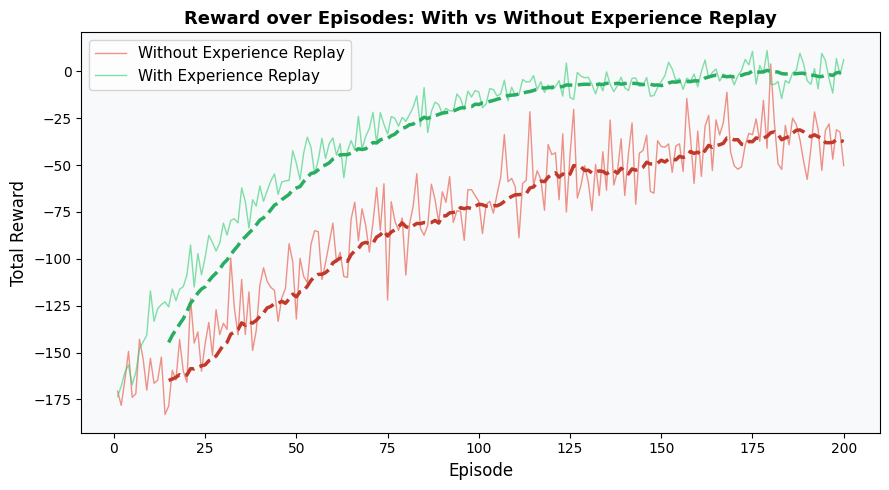

In [5]:
# Setup step: import the libraries that will carry the math, plotting, and learning logic.
# Reading the imports first helps students see which tools each later cell depends on.

# Load a library so you can use its ready-made functions and types below.
import matplotlib.pyplot as plt
# Load a library so you can use its ready-made functions and types below.
import numpy as np

# Use NumPy for fast numeric arrays and math on grids of numbers.
np.random.seed(42)
# Save a value in a name so the next lines can read it.
episodes = np.arange(1, 201)

# Without experience replay: noisier, slower convergence
# Save a value in a name so the next lines can read it.
noise_no_er = np.random.randn(200) * 15
# Unpack the one-step model output from transition(state, action).
reward_no_er = -180 + 160 * (1 - np.exp(-episodes / 80)) + noise_no_er

# With experience replay: smoother, faster convergence
# Save a value in a name so the next lines can read it.
noise_er = np.random.randn(200) * 6
# Unpack the one-step model output from transition(state, action).
reward_er = -180 + 180 * (1 - np.exp(-episodes / 40)) + noise_er

# Unpack Matplotlib figure and axes array created by subplots().
fig, ax = plt.subplots(figsize=(9, 5))
# Work on one plot panel: title, tick marks, axis labels, or drawings on that panel.
ax.plot(episodes, reward_no_er, color='#e74c3c', alpha=0.6, linewidth=1, label='Without Experience Replay')
# Same plot panel as the line above—one more small plotting tweak.
ax.plot(episodes, reward_er,   color='#2ecc71', alpha=0.6, linewidth=1, label='With Experience Replay')

# Smoothed lines
# Save a value in a name so the next lines can read it.
window = 15
# Same plot panel as the line above—one more small plotting tweak.
ax.plot(episodes[window-1:], np.convolve(reward_no_er, np.ones(window)/window, mode='valid'),
        # Save a value in a name so the next lines can read it.
        color='#c0392b', linewidth=2.5, linestyle='--')
# Same plot panel as the line above—one more small plotting tweak.
ax.plot(episodes[window-1:], np.convolve(reward_er, np.ones(window)/window, mode='valid'),
        # Save a value in a name so the next lines can read it.
        color='#27ae60', linewidth=2.5, linestyle='--')

# Same plot panel as the line above—one more small plotting tweak.
ax.set_xlabel('Episode', fontsize=12)
# Same plot panel as the line above—one more small plotting tweak.
ax.set_ylabel('Total Reward', fontsize=12)
# Same plot panel as the line above—one more small plotting tweak.
ax.set_title('Reward over Episodes: With vs Without Experience Replay', fontsize=13, fontweight='bold')
# Same plot panel as the line above—one more small plotting tweak.
ax.legend(fontsize=11)
# Same plot panel as the line above—one more small plotting tweak.
ax.set_facecolor('#f8f9fa')
# Change something about the whole figure (not just one small subplot).
fig.patch.set_facecolor('white')
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.tight_layout()
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.show()


## 🌍 Real-World Worked Example — CartPole with DQN

**Industry context:**
- Practical RL systems often need replay design, reward design, and hyperparameter tuning in addition to the core algorithm
- Robotics and control tasks often rely on more advanced methods than the tiny teaching setup shown here
- CartPole is used here as a compact teaching proxy, not as a direct model of production systems

We train a **DQN agent** to balance a pole on a cart using raw observations from OpenAI Gymnasium.

### Step Guide

**What this cell does:** Import libraries and set small global constants for the lesson.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


Episode   0 | Avg reward (last 30): 17.0 | ε=0.995


Episode  30 | Avg reward (last 30): 25.3 | ε=0.856


Episode  60 | Avg reward (last 30): 33.2 | ε=0.737


Episode  90 | Avg reward (last 30): 25.3 | ε=0.634


Episode 120 | Avg reward (last 30): 37.7 | ε=0.545


Episode 150 | Avg reward (last 30): 32.8 | ε=0.469


Episode 180 | Avg reward (last 30): 21.9 | ε=0.404


Episode 210 | Avg reward (last 30): 43.0 | ε=0.347


Episode 240 | Avg reward (last 30): 42.3 | ε=0.299


Episode 270 | Avg reward (last 30): 55.9 | ε=0.257


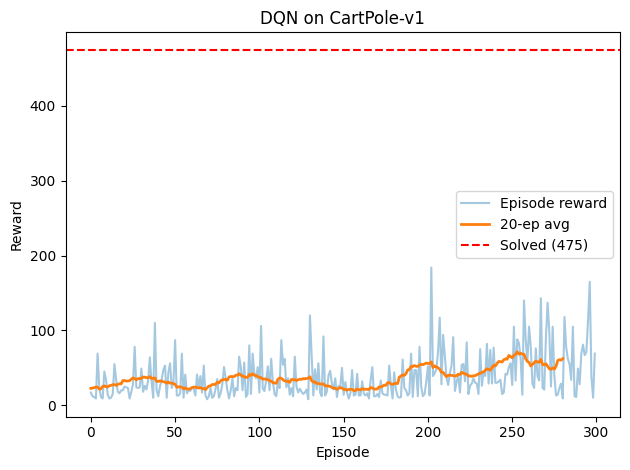

In [6]:
# Setup step: import the libraries that will carry the math, plotting, and learning logic.
# Reading the imports first helps students see which tools each later cell depends on.

# Load a library so you can use its ready-made functions and types below.
import torch, torch.nn as nn, torch.optim as optim
# Load a library so you can use its ready-made functions and types below.
import gymnasium as gym
# Load a library so you can use its ready-made functions and types below.
import numpy as np, random, collections, matplotlib.pyplot as plt

# Call a PyTorch API (tensor/module/training-related).
torch.manual_seed(42); np.random.seed(42)

# Save a value in a name so the next lines can read it.
env = gym.make('CartPole-v1')

# ── DQN Network ──────────────────────────────────────────────────────────
# Class `DQN` (what it does): defines an object blueprint (attributes + methods); read the indented block to see each part.
class DQN(nn.Module):
    # Function `__init__` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: self, obs, act.
    def __init__(self, obs=4, act=2):
        # Execute: super().__init__()
        super().__init__()
        # Save a value in a name so the next lines can read it.
        self.net = nn.Sequential(
            # Call a PyTorch API (tensor/module/training-related).
            nn.Linear(obs,128), nn.ReLU(),
            # Call a PyTorch API (tensor/module/training-related).
            nn.Linear(128,128), nn.ReLU(),
            # Call a PyTorch API (tensor/module/training-related).
            nn.Linear(128, act)
        # Close the parentheses opened earlier (end this function call / grouping).
        )
    # Function `forward` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: self, x.
    def forward(self, x): return self.net(x)

# Create or update the greedy policy array (one int action id per state).
policy_net = DQN(); target_net = DQN()
# Execute: target_net.load_state_dict(policy_net.state_dict())
target_net.load_state_dict(policy_net.state_dict())
# Save a value in a name so the next lines can read it.
opt     = optim.Adam(policy_net.parameters(), lr=1e-3)
# Another assignment—same idea: store a value for the lines below.
memory  = collections.deque(maxlen=10000)
# Set discount factor gamma used inside r + gamma * V(s') targets.
GAMMA   = 0.99; EPS = 1.0; EPS_MIN = 0.05; EPS_DECAY = 0.995
# Save a value in a name so the next lines can read it.
BATCH   = 64; rewards_ep = []

# Start a loop: repeat the indented block once per item in the sequence.
for episode in range(300):
    # Save a value in a name so the next lines can read it.
    obs,_ = env.reset(); total_r = 0
    # Start a loop: repeat the indented block once per item in the sequence.
    for t in range(500):
        # If the condition is True, run the indented block under this line.
        if random.random() < EPS:
            # Save a value in a name so the next lines can read it.
            action = env.action_space.sample()
        # Else: run this block when none of the if/elif tests above matched.
        else:
            # Safely open/use a resource; Python cleans up when the block ends.
            with torch.no_grad():
                # Save a value in a name so the next lines can read it.
                action = policy_net(torch.tensor(obs).float().unsqueeze(0)).argmax().item()
        # Another assignment—same idea: store a value for the lines below.
        obs2, r, done, trunc, _ = env.step(action)
        # Add one new item to the end of a list (the list grows in place).
        memory.append((obs, action, r, obs2, done or trunc))
        # Save a value in a name so the next lines can read it.
        obs = obs2; total_r += r
        # ── Train ────────────────────────────────────────────────────────
        # If the condition is True, run the indented block under this line.
        if len(memory) >= BATCH:
            # Save a value in a name so the next lines can read it.
            batch = random.sample(memory, BATCH)
            # Another assignment—same idea: store a value for the lines below.
            s,a,r_b,s2,d = zip(*batch)
            # Another assignment—same idea: store a value for the lines below.
            S=torch.tensor(np.array(s)).float(); A=torch.tensor(a).long()
            # Another assignment—same idea: store a value for the lines below.
            R=torch.tensor(r_b).float(); S2=torch.tensor(np.array(s2)).float()
            # Another assignment—same idea: store a value for the lines below.
            D=torch.tensor(d).float()
            # Another assignment—same idea: store a value for the lines below.
            Q_pred = policy_net(S).gather(1,A.unsqueeze(1)).squeeze()
            # Safely open/use a resource; Python cleans up when the block ends.
            with torch.no_grad():
                # Save a value in a name so the next lines can read it.
                Q_next = target_net(S2).max(1)[0]
            # Another assignment—same idea: store a value for the lines below.
            Q_target = R + GAMMA*Q_next*(1-D)
            # Another assignment—same idea: store a value for the lines below.
            loss = nn.MSELoss()(Q_pred, Q_target)
            # Execute: opt.zero_grad(); loss.backward(); opt.step()
            opt.zero_grad(); loss.backward(); opt.step()
        # If the condition is True, run the indented block under this line.
        if done or trunc: break
    # Save a value in a name so the next lines can read it.
    EPS = max(EPS*EPS_DECAY, EPS_MIN)
    # Add one new item to the end of a list (the list grows in place).
    rewards_ep.append(total_r)
    # If the condition is True, run the indented block under this line.
    if episode%50==0: target_net.load_state_dict(policy_net.state_dict())
    # If the condition is True, run the indented block under this line.
    if episode%30==0: print(f"Episode {episode:3d} | Avg reward (last 30): {np.mean(rewards_ep[-30:]):.1f} | ε={EPS:.3f}")

# Execute: env.close()
env.close()
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.plot(rewards_ep, alpha=0.4, label="Episode reward")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.plot(np.convolve(rewards_ep, np.ones(20)/20, 'valid'), label="20-ep avg", lw=2)
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.title("DQN on CartPole-v1"); plt.xlabel("Episode"); plt.ylabel("Reward")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.axhline(475, color='red', linestyle='--', label="Solved (475)"); plt.legend()
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.tight_layout(); plt.show()


## CartPole step-through (GIF + slider)

Same **rgb_array** replay pattern as other Course 09 notebooks: **random** actions for a quick visual anchor while you study replay + shaping code above.

In [ ]:
%pip install ipywidgets pillow -q

import pathlib
import sys

for _d in [pathlib.Path.cwd().resolve(), *pathlib.Path.cwd().resolve().parents]:
    if (_d / "course09_step_viz.py").exists():
        _course09 = _d
        break
else:
    raise FileNotFoundError("Could not find course09_step_viz.py — run from inside Course 09.")

if str(_course09) not in sys.path:
    sys.path.insert(0, str(_course09))

import gymnasium as gym
import course09_step_viz as cs9viz

env_vis = gym.make("CartPole-v1", render_mode="rgb_array")


def random_policy(obs, step):
    return int(env_vis.action_space.sample())


frames, total_r, term, trunc = cs9viz.collect_rollout_frames(
    env_vis, random_policy, max_steps=100, seed=0
)
env_vis.close()

print(f"{len(frames)} frames | return={total_r:.1f} | term={term} | trunc={trunc}")
cs9viz.display_gif(frames, duration_ms=110)
cs9viz.display_step_slider(frames, title="CartPole-v1 timestep")

## Summary

### Key Techniques:
1. **Experience Replay**: Store and randomly sample past experiences
2. **Reward Shaping**: Add shaping rewards to guide learning
3. **Hyperparameter Tuning**: Optimize learning parameters

### Benefits:
- **Experience Replay**: Sample efficiency, stability, decorrelation
- **Reward Shaping**: Faster convergence, better guidance
- **Hyperparameter Tuning**: Better performance when settings are chosen well

### Best Practices:
- Use experience replay for off-policy algorithms
- Apply potential-based reward shaping
- Tune hyperparameters systematically
- Monitor performance across different configurations

Teaching note: some early plots in this notebook are conceptual illustrations for explanation, while the final DQN section is the closest part to an actual training run.

**Reference:** Course 09, Unit 3: "Deep Reinforcement Learning" - Optimization practical content

In [ ]:
# References (shown with Markdown inside a Python cell — avoids SyntaxError if a Markdown block is run as code.)
from IPython.display import Markdown, display

display(Markdown(r"""## 📚 References & Further Reading

### Papers
- Watkins & Dayan (1992) — [Q-Learning](https://link.springer.com/article/10.1007/BF00992698)
- Mnih et al. (2015) — [DQN: Human-level control via deep RL](https://www.nature.com/articles/nature14236)
- Van Hasselt et al. (2016) — [Double DQN](https://arxiv.org/abs/1509.06461)

**OpenAI Gym:** [Gymnasium Documentation](https://gymnasium.farama.org/)

### State-of-the-art DQN variants power game-playing AI and robotics controllers at Google DeepMind.
"""))


### Step Guide

**What this cell does:** Try to auto-plot lesson numbers already in memory (optional recap charts).

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Either one or more plots, or a short message that nothing was auto-plotted.

**If you feel lost:** Re-run the main lesson cells so numeric variables exist, then try this recap again.


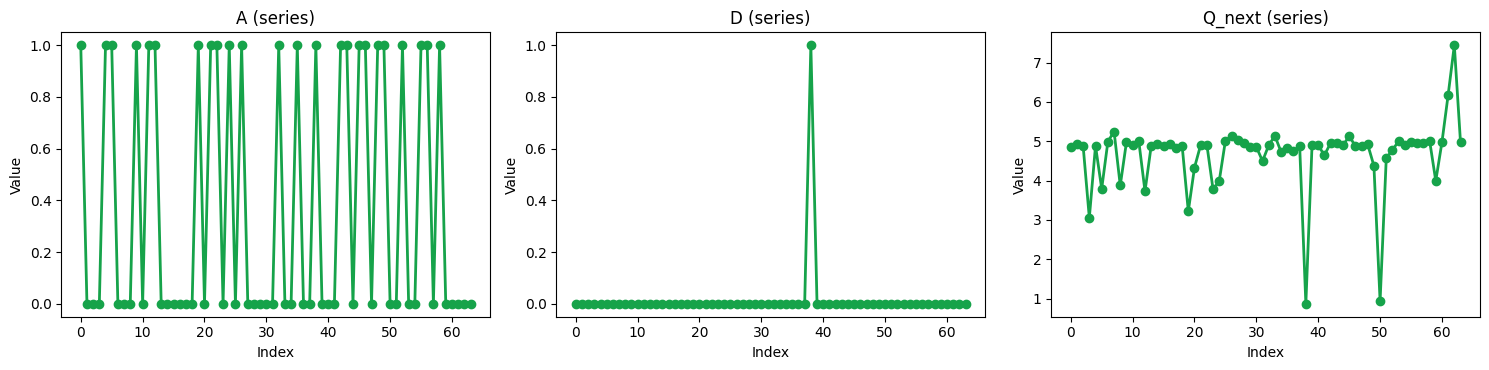

In [7]:
# Visual recap: turn the lesson's numeric artifacts into quick charts.
# The goal is to help students see patterns that are harder to catch from raw printed output alone.
# Load a library so you can use its ready-made functions and types below.
import numbers
# Load a library so you can use its ready-made functions and types below.
import numpy as np
# Load a library so you can use its ready-made functions and types below.
import matplotlib.pyplot as plt

# Function `_is_number` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value.
def _is_number(value):
    # Send a value back to whoever called this function.
    return isinstance(value, (int, float, np.integer, np.floating)) and not isinstance(value, bool)

# Function `_as_numeric_dict` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value.
def _as_numeric_dict(value):
    # If the condition is True, run the indented block under this line.
    if not isinstance(value, dict) or not value or len(value) > 12:
        # Send a value back to whoever called this function.
        return None
    # Collect numeric dict values after validation for plotting.
    converted = []
    # Start a loop: repeat the indented block once per item in the sequence.
    for item in value.values():
        # If the condition is True, run the indented block under this line.
        if not _is_number(item):
            # Send a value back to whoever called this function.
            return None
        # Add one new item to the end of a list (the list grows in place).
        converted.append(float(item))
    # Send a value back to whoever called this function.
    return [str(key) for key in value.keys()], np.asarray(converted, dtype=float)

# Function `_as_numeric_array` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value, dims.
def _as_numeric_array(value, dims):
    # Try/except/finally: structured error handling around risky operations.
    try:
        # Temporary ndarray after coercion attempt inside _as_numeric_array().
        array = np.asarray(value, dtype=float)
    # Try/except/finally: structured error handling around risky operations.
    except Exception:
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if array.ndim != dims:
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if dims == 1 and not (2 <= array.size <= 200):
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if dims == 2 and array.size > 400:
        # Send a value back to whoever called this function.
        return None
    # Send a value back to whoever called this function.
    return array

# Preferred global names to try first when auto-picking lesson plots.
priority_names = [
    # Execute: "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    # Execute: "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores …
    "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores"
# Execute: ]
]

# Names that are never lesson metrics (imports / plotting handles).
skip_names = {"np", "plt", "numbers", "math", "Figure", "fig"}
# Save a value in a name so the next lines can read it.
candidates = []
# Track which names were already visited to avoid duplicates.
seen = set()
# Ordered list of global names to scan for plottable numeric artifacts.
search_space = priority_names + sorted(name for name in globals() if not name.startswith("_"))

# Start a loop: repeat the indented block once per item in the sequence.
for name in search_space:
    # If the condition is True, run the indented block under this line.
    if name in seen or name not in globals() or name in skip_names:
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue
    # Execute: seen.add(name)
    seen.add(name)
    # The runtime object bound to that global name.
    value = globals()[name]

    # Try to interpret a global variable as a plottable payload (or None if not).
    dict_payload = _as_numeric_dict(value)
    # If the condition is True, run the indented block under this line.
    if dict_payload is not None:
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("dict", name, dict_payload))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_2d = _as_numeric_array(value, 2)
    # If the condition is True, run the indented block under this line.
    if array_2d is not None:
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("heatmap", name, array_2d))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_1d = _as_numeric_array(value, 1)
    # If the condition is True, run the indented block under this line.
    if array_1d is not None:
        # Append one value to a list (mutates the list in place).
        # Skip misleading line plots for last-step env vectors (not time series).
        # If the condition is True, run the indented block under this line.
        if name in {"obs", "next_obs", "state", "action"} and array_1d.size <= 16:
            # Skip to the next lap of the loop (ignore the rest of this lap).
            continue
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("line", name, array_1d))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break

# If the condition is True, run the indented block under this line.
if not candidates:
    # Build a small dict used only for the fallback summary bar chart.
    summary = {
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "functions": sum(callable(value) for value in globals().values()),
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "classes": sum(isinstance(value, type) for value in globals().values()),
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "numeric vars": sum(_is_number(value) for value in globals().values()),
    # Part of a dict/set literal layout (syntax grouping).
    }
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, ax = plt.subplots(figsize=(6, 3.5))
    # Work on one plot panel: title, tick marks, axis labels, or drawings on that panel.
    ax.bar(summary.keys(), summary.values(), color=["#2563eb", "#16a34a", "#f59e0b"])
    # Same plot panel as the line above—one more small plotting tweak.
    ax.set_title("Notebook artifact summary")
    # Same plot panel as the line above—one more small plotting tweak.
    ax.set_ylabel("Count")
    # Start a loop: repeat the indented block once per item in the sequence.
    for idx, value in enumerate(summary.values()):
        # Same plot panel as the line above—one more small plotting tweak.
        ax.text(idx, value + 0.05, str(value), ha="center")
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.tight_layout()
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.show()
# Else: run this block when none of the if/elif tests above matched.
else:
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, axes = plt.subplots(1, len(candidates), figsize=(5 * len(candidates), 3.8))
    # If the condition is True, run the indented block under this line.
    if len(candidates) == 1:
        # Save a value in a name so the next lines can read it.
        axes = [axes]

    # Start a loop: repeat the indented block once per item in the sequence.
    for ax, (kind, name, payload) in zip(axes, candidates):
        # If the condition is True, run the indented block under this line.
        if kind == "dict":
            # Unpack plotting payload for dict bar charts (keys vs numeric values).
            labels, values = payload
            # Work on one plot panel: title, tick marks, axis labels, or drawings on that panel.
            ax.bar(range(len(values)), values, color="#2563eb")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xticks(range(len(values)))
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xticklabels(labels, rotation=45, ha="right")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (dict)")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_ylabel("Value")
        # Else-if: only checked when the earlier if/elif tests were False.
        elif kind == "line":
            # Same plot panel as the line above—one more small plotting tweak.
            ax.plot(payload, marker="o", linewidth=2, color="#16a34a")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (series)")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xlabel("Index")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_ylabel("Value")
        # Else: run this block when none of the if/elif tests above matched.
        else:
            # Image handle returned by imshow for attaching a colorbar.
            image = ax.imshow(payload, aspect="auto", cmap="viridis")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (heatmap)")
            # Change something about the whole figure (not just one small subplot).
            fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.tight_layout()
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.show()


## Closing Takeaway

**Teaching takeaway:** Optimization tricks such as replay design and reward shaping can make learning faster, but they must preserve the real task objective.

**If students remember one idea:** A helpful engineering trick becomes harmful when it changes what success actually means.

**Quick check before moving on:**
- Can you explain how reward shaping can help without replacing the true goal?
- Can you describe why optimization choices should be judged by learning behavior, not by speed alone?

**Bridge to the next step:** This completes the deep RL foundation and prepares students to think more carefully about exploration in Unit 4.

**For weaker coders:** After you run the important cells, write one sentence: *what number or plot changed, and does that match what the lesson said should happen?* If not, re-read only the `#` hint lines in that cell—not every line of Python.
